<a href="https://colab.research.google.com/github/risnariha/-Multivariate-Time-Series-Prediction-Model/blob/main/EDA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[]


In [19]:
!pip install tensorflow scikit-learn seaborn matplotlib pandas numpy

In [20]:
#data_preprocessing

In [45]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def preprocess_data(file_path):

    df = pd.read_csv(file_path)

    df['date'] = pd.to_datetime(df['date'])

    df = df.sort_values('date')

    print(df.isnull().sum())

    df = df.interpolate(method='linear')

    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df['Appliances'])
    plt.title("Outlier Detection")
    plt.show()

    return df


In [22]:
#feature engineering

In [23]:

def engineer_features(df):

    df['hour'] = df['date'].dt.hour
    df['day'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek

    df['lag_1'] = df['Appliances'].shift(1)
    df['lag_6'] = df['Appliances'].shift(6)
    df['lag_12'] = df['Appliances'].shift(12)
    df['lag_24'] = df['Appliances'].shift(24)

    df['rolling_mean_6'] = df['Appliances'].rolling(6).mean()
    df['rolling_mean_12'] = df['Appliances'].rolling(12).mean()

    df['temp_humidity'] = df['T1'] * df['RH_1']

    df = df.dropna()

    selected_features = [
        'lag_1',
        'lag_6',
        'lag_12',
        'lag_24',
        'rolling_mean_6',
        'rolling_mean_12',
        'hour',
        'day',
        'month',
        'day_of_week',
        'lights',
        'T1',
        'T2',
        'T6',
        'RH_1',
        'T_out',
        'Windspeed',
        'temp_humidity'
    ]

    return df, selected_features


In [24]:
#sequence_builder

In [25]:

import numpy as np

def create_sequences(X, y, time_steps=24):

    Xs = []
    ys = []

    for i in range(len(X) - time_steps):

        Xs.append(X.iloc[i:(i + time_steps)].values)

        ys.append(y.iloc[i + time_steps])

    return np.array(Xs), np.array(ys)


In [26]:
#1 baseline model

In [27]:

import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

def train_baseline_models(X_train, X_test, y_train, y_test):

    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(
            n_estimators=100,
            random_state=42
        )
    }

    for name, model in models.items():

        print(f"Training {name}...")

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, pred)

        rmse = np.sqrt(
            mean_squared_error(y_test, pred)
        )

        print(f"{name} MAE: {mae:.4f}")
        print(f"{name} RMSE: {rmse:.4f}")


In [28]:
#LSTM

In [29]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Input
)

def build_lstm_model(input_shape):

    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(
        LSTM(
            128,
            return_sequences=True
        )
    )

    model.add(Dropout(0.3))

    model.add(LSTM(64))

    model.add(Dropout(0.3))

    model.add(Dense(16, activation='relu'))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


In [30]:
#build_bidirectional_lstm_model

In [31]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Bidirectional,
    Input
)

def build_bidirectional_lstm_model(
    input_shape
):

    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(
        Bidirectional(
            LSTM(
                128,
                return_sequences=True
            )
        )
    )

    model.add(Dropout(0.3))

    model.add(
        Bidirectional(
            LSTM(64)
        )
    )

    model.add(Dropout(0.3))

    model.add(Dense(32, activation='relu'))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


In [32]:
#_gru_model

In [33]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout,
    Input
)

def build_gru_model(input_shape):

    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(
        GRU(
            128,
            return_sequences=True
        )
    )

    model.add(Dropout(0.3))

    model.add(GRU(64))

    model.add(Dropout(0.3))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


In [34]:
#lstm_gru_hybrid_model

In [35]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    GRU,
    Dense,
    Dropout,
    Input
)

def build_lstm_gru_hybrid_model(
    input_shape
):

    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(
        LSTM(
            128,
            return_sequences=True
        )
    )

    model.add(Dropout(0.3))

    model.add(GRU(64))

    model.add(Dropout(0.3))

    model.add(Dense(32, activation='relu'))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


In [36]:
#cnn_lstm_model

In [37]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout,
    Input
)

def build_cnn_lstm_model(input_shape):

    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(
        Conv1D(
            filters=64,
            kernel_size=3,
            activation='relu'
        )
    )

    model.add(MaxPooling1D(pool_size=2))

    model.add(
        LSTM(
            64,
            return_sequences=True
        )
    )

    model.add(Dropout(0.3))

    model.add(LSTM(32))

    model.add(Dropout(0.3))

    model.add(Dense(16, activation='relu'))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


In [38]:
#TRAINING

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64


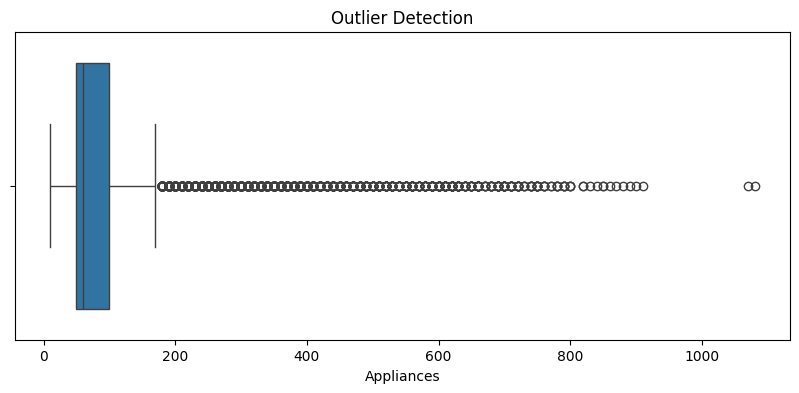

Training Linear Regression...
Linear Regression MAE: 30.1172
Linear Regression RMSE: 59.6236
Training Random Forest...
Random Forest MAE: 35.6403
Random Forest RMSE: 69.2578
Training LSTM
Epoch 1/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - loss: 0.0083 - mae: 0.0508 - val_loss: 0.0059 - val_mae: 0.0456
Epoch 2/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - loss: 0.0073 - mae: 0.0456 - val_loss: 0.0056 - val_mae: 0.0380
Epoch 3/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 0.0068 - mae: 0.0431 - val_loss: 0.0050 - val_mae: 0.0340
Epoch 4/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - loss: 0.0063 - mae: 0.0411 - val_loss: 0.0049 - val_mae: 0.0300
Epoch 5/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - loss: 0.0061 - mae: 0.0397 - val_loss: 0.0048 - val_mae: 0.0329
Epoch 6/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - loss: 0.0058 - mae: 0.0389 - val_loss: 0.0047 - val_mae: 0.0312
Epoch 7/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - loss: 0.0055 - mae: 0.0381 - val_los

In [42]:
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.callbacks import EarlyStopping

def main():

    # Fixed the file path by adding a leading slash for the absolute path in Colab
    FILE_PATH = '/content/energy_data_set.csv'

    df = preprocess_data(FILE_PATH)

    df, selected_features = (
        engineer_features(df)
    )

    X = df[selected_features]

    y = df['Appliances']

    split_index = int(len(df) * 0.8)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    train_baseline_models(
        X_train,
        X_test,
        y_train,
        y_test
    )

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(X)

    y_scaled = scaler_y.fit_transform(
        y.values.reshape(-1, 1)
    ).flatten()

    X_scaled = pd.DataFrame(
        X_scaled,
        columns=selected_features
    )

    y_scaled = pd.Series(y_scaled)

    X_train_scaled = X_scaled.iloc[:split_index]
    X_test_scaled = X_scaled.iloc[split_index:]

    y_train_scaled = y_scaled.iloc[:split_index]
    y_test_scaled = y_scaled.iloc[split_index:]

    X_train_seq, y_train_seq = (
        create_sequences(
            X_train_scaled,
            y_train_scaled
        )
    )

    X_test_seq, y_test_seq = (
        create_sequences(
            X_test_scaled,
            y_test_scaled
        )
    )

    models = {
        'LSTM': build_lstm_model,
        'GRU': build_gru_model,
        'BiLSTM': build_bidirectional_lstm_model,
        'CNN-LSTM': build_cnn_lstm_model,
        'LSTM-GRU': build_lstm_gru_hybrid_model
    }

    for name, builder in models.items():

        print(f"Training {name}")

        model = builder(
            (
                X_train_seq.shape[1],
                X_train_seq.shape[2]
            )
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train_seq,
            y_train_seq,
            validation_split=0.1,
            epochs=20,
            batch_size=32,
            callbacks=[early_stop],
            verbose=1
        )

        pred = model.predict(X_test_seq)

        pred_actual = scaler_y.inverse_transform(pred)

        y_actual = scaler_y.inverse_transform(
            y_test_seq.reshape(-1, 1)
        )

        evaluate_model(
            y_actual,
            pred_actual,
            name
        )

        model.save(
            f'models/{name}.keras'
        )

    print("Training Completed")

if __name__ == '__main__':
    main()